<a href="https://colab.research.google.com/github/mammu2007/myproject.ipynb/blob/main/myproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

,Order_ID,Customer_ID,Order_Time,Location,Item,Category,Quantity,Price,Rating
0,1001,C058,2025-01-06 21:13:00,Trichy,Burger,Fast Food,2,180,3.9
1,1002,C037,2025-01-23 09:29:00,Chennai,Biryani,Main Course,1,220,4.4
2,1003,C049,2025-01-23 20:43:00,Coimbatore,Pizza,Fast Food,3,250,4.2
3,1004,C049,2025-01-29 03:24:00,Madurai,Biryani,Main Course,1,220,4.0
4,1005,C044,2025-01-15 07:35:00,Chennai,Biryani,Main Course,3,220,4.5
5,1006,C016,2025-01-18 16:46:00,Coimbatore,Pizza,Fast Food,1,250,4.6
6,1007,C015,2025-01-03 15:37:00,Trichy,Pizza,Fast Food,4,250,4.1
7,1008,C004,2025-01-30 01:21:00,Madurai,Burger,Fast Food,1,180,4.0
8,1009,C016,2025-01-16 06:36:00,Madurai,Fried Rice,Chinese,3,160,3.9
9,1010,C058,2025-01-20 01:29:00,Trichy,Noodles,Chinese,3,140,3.9


DataFrame head after loading new data:
   Order_ID Customer_ID           Order_Time    Location     Item  \
0      1001        C058  2025-01-06 21:13:00      Trichy   Burger   
1      1002        C037  2025-01-23 09:29:00     Chennai  Biryani   
2      1003        C049  2025-01-23 20:43:00  Coimbatore    Pizza   
3      1004        C049  2025-01-29 03:24:00     Madurai  Biryani   
4      1005        C044  2025-01-15 07:35:00     Chennai  Biryani   

      Category  Quantity  Price  Rating  
0    Fast Food         2    180     3.9  
1  Main Course         1    220     4.4  
2    Fast Food         3    250     4.2  
3  Main Course         1    220     4.0  
4  Main Course         3    220     4.5  
Rows: 200
Columns: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Order_ID     200 non-null    int64  
 1   Customer_ID  200 non-null    object 
 

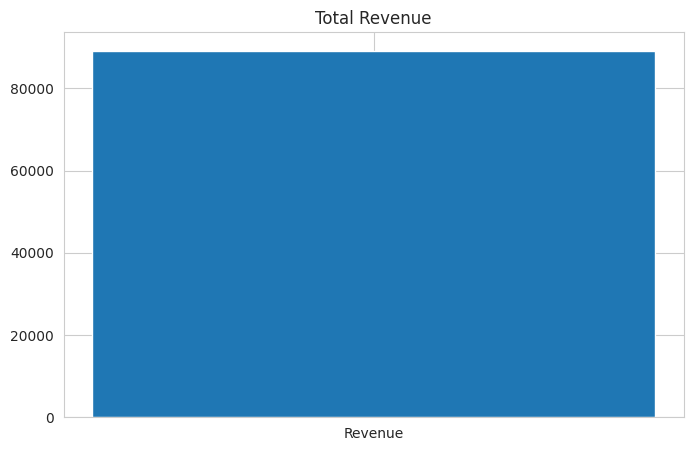

Day
Friday       27
Monday       25
Saturday     29
Sunday       21
Thursday     49
Tuesday      25
Wednesday    24
Name: Order_ID, dtype: int64


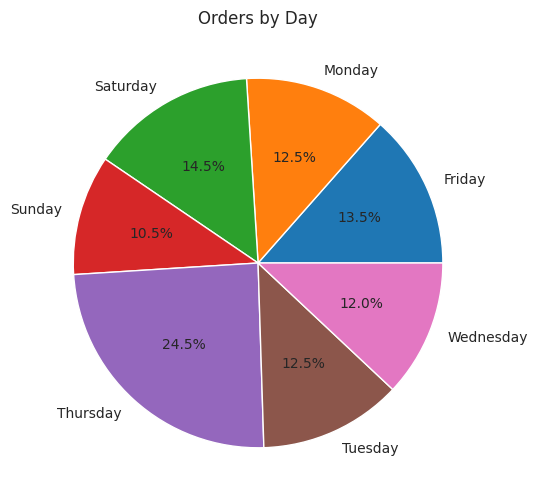

Location
Trichy        23430
Coimbatore    18510
Chennai       16900
Salem         15440
Madurai       14930
Name: Sales, dtype: int64


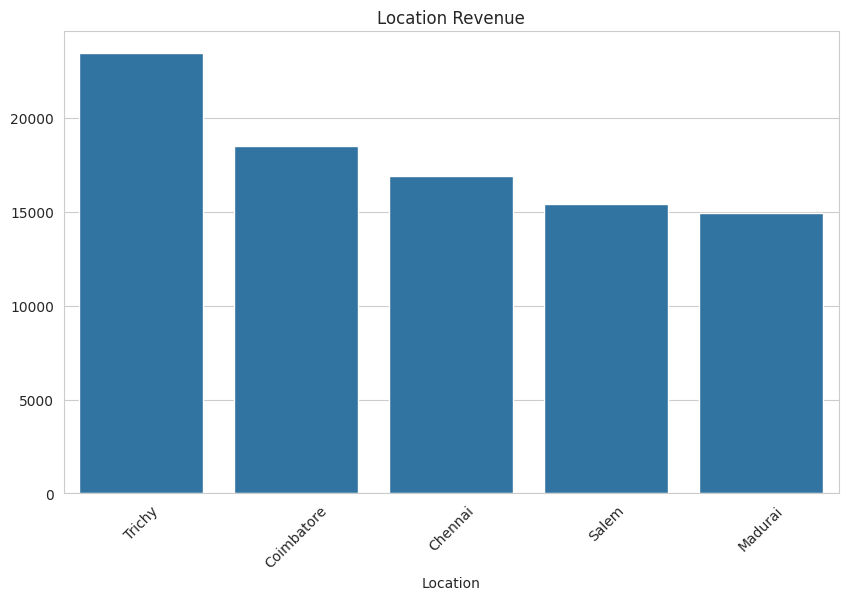

Customer_ID
C001    5
C002    4
C003    1
C004    7
C005    2
Name: Order_ID, dtype: int64
Customer_ID
C058    10
C004     7
C042     7
C054     7
C018     7
C007     6
C051     6
C001     5
C016     5
C022     5
Name: Order_ID, dtype: int64


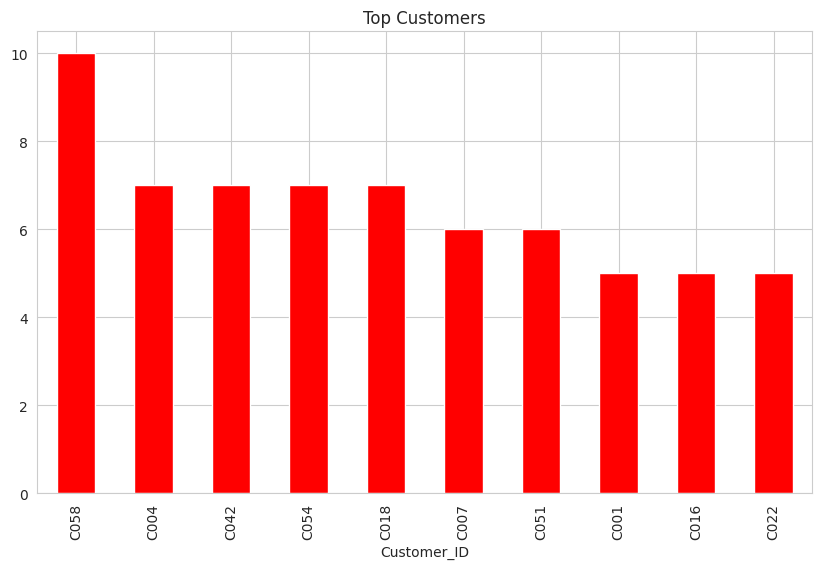

Month
January    89210
Name: Sales, dtype: int64


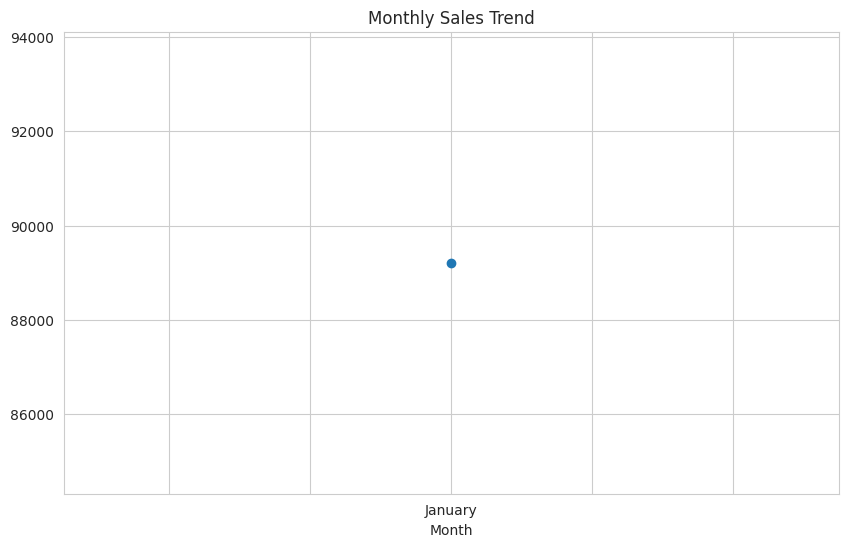

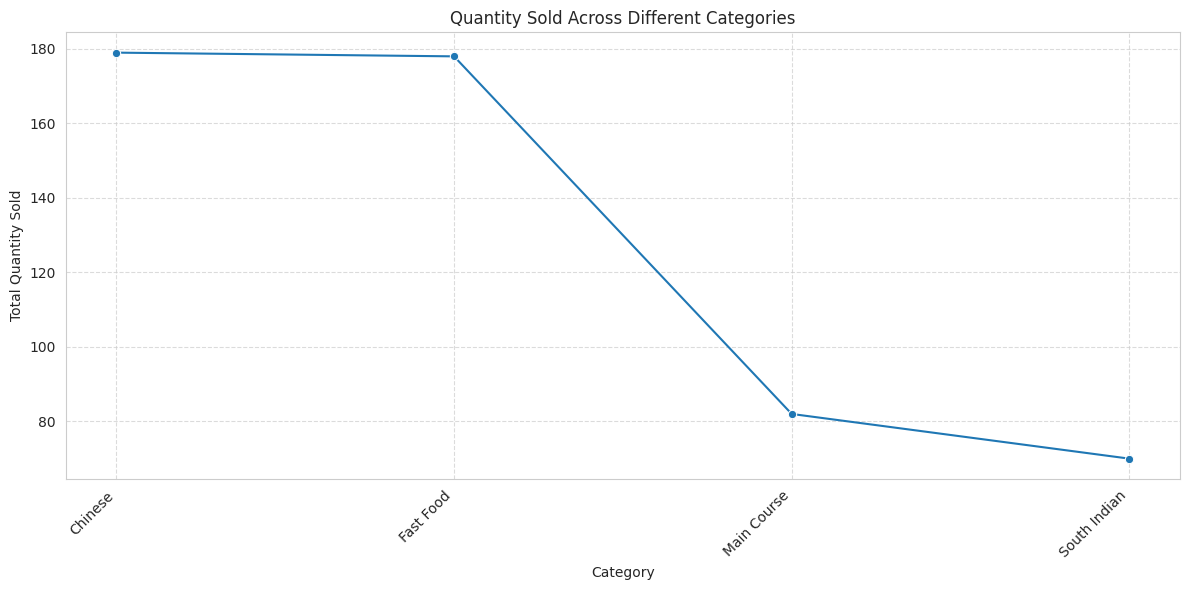

          Quantity     Price     Sales    Rating
Quantity  1.000000  0.032830  0.811131 -0.053597
Price     0.032830  1.000000  0.556652 -0.039074
Sales     0.811131  0.556652  1.000000 -0.087198
Rating   -0.053597 -0.039074 -0.087198  1.000000


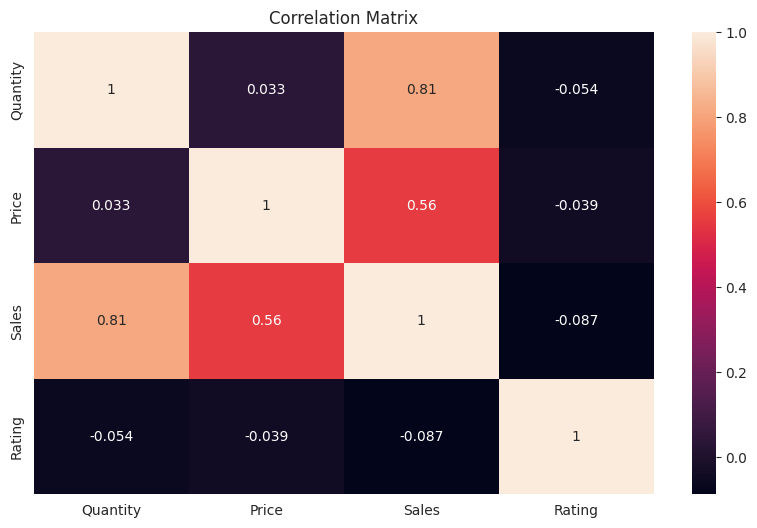

FOOD DELIVERY BUSINESS INSIGHTS

Total Revenue: 89210

Best Performing Location: Trichy


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Restore general plot settings
plt.rcParams['figure.figsize'] = (10,6)
sns.set_style("whitegrid")


# df is correctly loaded here from food_delivery_data.csv
df = pd.read_csv("food_delivery_data.csv")
df.head()
display(df.head(10))


print("DataFrame head after loading new data:")
print(df.head())

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

df.describe()

print(df.isnull().sum())

df.drop_duplicates(inplace=True)

df.dropna(inplace=True)

df['Order_Date'] = pd.to_datetime(df['Order_Time'])

df['Day'] = df['Order_Date'].dt.day_name()

df['Month'] = df['Order_Date'].dt.month_name()


df['Sales'] = df['Quantity'] * df['Price']

total_sales = df['Sales'].sum()

print("Total Revenue:", total_sales)

plt.figure(figsize=(8,5))

plt.bar(["Revenue"], [total_sales])

plt.title("Total Revenue")

plt.show()

daily_orders = df.groupby('Day')['Order_ID'].count()

print(daily_orders)

daily_orders.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Orders by Day")

plt.ylabel("")

plt.show()


location_sales = df.groupby(
    'Location'
)['Sales'].sum()

location_sales = location_sales.sort_values(
    ascending=False
)

print(location_sales)

sns.barplot(
    x=location_sales.index,
    y=location_sales.values
)

plt.xticks(rotation=45)

plt.title("Location Revenue")

plt.show()


customer_orders = df.groupby(
    'Customer_ID'
)['Order_ID'].count()

print(customer_orders.head())

top_customers = customer_orders.sort_values(
    ascending=False
)

print(top_customers.head(10))
top_customers.head(10).plot(
    kind='bar',color='red'
)

plt.title("Top Customers")

plt.show()

monthly_sales = df.groupby(
    'Month'
)['Sales'].sum()

print(monthly_sales)

monthly_sales.plot(
    marker='o'
)

plt.title("Monthly Sales Trend")

plt.show()

category_quantity = df.groupby('Category')['Quantity'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.lineplot(x=category_quantity.index, y=category_quantity.values, marker='o')
plt.title('Quantity Sold Across Different Categories')
plt.xlabel('Category')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



corr = df[
    ['Quantity',
     'Price',
     'Sales',
     'Rating']
].corr()

print(corr)
sns.heatmap(
    corr,
    annot=True
)

plt.title("Correlation Matrix")

plt.show()


print("="*50)
print("FOOD DELIVERY BUSINESS INSIGHTS")
print("="*50)

print(
    "\nTotal Revenue:",
    round(total_sales,2)
)



print(
    "\nBest Performing Location:",
    location_sales.idxmax()
)


print("="*50)